# DL RV Prediction (Single CSV)

This notebook trains neural networks to predict `rv_shift_ms` from CCF features in:
- `saved_spectra/random_2000ccf_with_rv.csv`

Expected columns: `sample_index`, `rv_shift_ms`, and many `ccf_####` feature columns.


In [48]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from scipy.optimize import curve_fit

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)


In [49]:
# Load single dataset file
base_dir = Path.cwd()
data_path = base_dir / "saved_spectra" / "random_3000ccf_with_rv_001step.csv"

if not data_path.exists():
    raise FileNotFoundError(f"Missing file: {data_path}")

df = pd.read_csv(data_path)
print("Dataset shape:", df.shape)
display(df.head())


Dataset shape: (3000, 3003)


,sample_index,rv_shift_ms,ccf_0000,ccf_0001,ccf_0002,ccf_0003,ccf_0004,ccf_0005,ccf_0006,ccf_0007,...,ccf_2991,ccf_2992,ccf_2993,ccf_2994,ccf_2995,ccf_2996,ccf_2997,ccf_2998,ccf_2999,ccf_3000
0,0,77.395605,0.697390,0.697400,0.697411,0.697421,0.697432,0.697443,0.697453,0.697464,...,0.698016,0.698009,0.698002,0.697995,0.697988,0.697981,0.697974,0.697967,0.697961,0.697954
1,1,43.887844,0.697425,0.697436,0.697447,0.697457,0.697468,0.697479,0.697491,0.697502,...,0.697992,0.697985,0.697978,0.697972,0.697965,0.697958,0.697952,0.697945,0.697938,0.697931
2,2,85.859792,0.697381,0.697391,0.697402,0.697412,0.697423,0.697434,0.697444,0.697455,...,0.698022,0.698015,0.698008,0.698001,0.697994,0.697987,0.697980,0.697973,0.697966,0.697960
3,3,69.736803,0.697398,0.697408,0.697419,0.697430,0.697440,0.697451,0.697462,0.697473,...,0.698010,0.698003,0.697996,0.697989,0.697982,0.697975,0.697969,0.697962,0.697956,0.697949
4,4,9.417735,0.697462,0.697473,0.697484,0.697496,0.697507,0.697519,0.697531,0.697543,...,0.697969,0.697962,0.697955,0.697949,0.697942,0.697935,0.697928,0.697922,0.697915,0.697909


In [50]:
# Prepare X/y
required_cols = {"sample_index", "rv_shift_ms"}
missing = required_cols - set(df.columns)
if missing:
    raise ValueError(f"Missing required column(s): {missing}")

ccf_cols = [c for c in df.columns if c.startswith("ccf_")]
# ccf_cols = ccf_cols[100:-100]  # optional: trim edges

if not ccf_cols:
    ccf_cols = [
        c for c in df.select_dtypes(include=[np.number]).columns
        if c not in {"sample_index", "rv_shift_ms"}
    ]

if not ccf_cols:
    raise ValueError("No CCF feature columns found.")

X = df[ccf_cols].to_numpy(dtype=np.float32)
y = pd.to_numeric(df["rv_shift_ms"], errors="coerce").to_numpy(dtype=np.float32).reshape(-1, 1)
if np.isnan(y).any():
    raise ValueError("Found non-numeric values in rv_shift_ms.")

ccf_vrad = np.arange(-15.0, 15.0 + 0.01, 0.01, dtype=np.float32)
if len(ccf_vrad) != X.shape[1]:
    raise ValueError(f"vrad length ({len(ccf_vrad)}) != CCF bins ({X.shape[1]})")

def _gaussian_absorption(v, amp, mu, sigma, cont):
    return cont - amp * np.exp(-0.5 * ((v - mu) / sigma) ** 2)

def estimate_rv_baseline_ms(ccf_vec, vrad_grid, window_half=6):
    idx0 = int(np.argmin(ccf_vec))
    lo = max(0, idx0 - window_half)
    hi = min(len(vrad_grid), idx0 + window_half + 1)

    v_win = vrad_grid[lo:hi].astype(np.float64)
    y_win = ccf_vec[lo:hi].astype(np.float64)

    try:
        cont0 = float(np.max(y_win))
        amp0 = float(max(cont0 - np.min(y_win), 1e-6))
        mu0 = float(vrad_grid[idx0])
        sigma0 = 0.3

        popt, _ = curve_fit(
            _gaussian_absorption,
            v_win,
            y_win,
            p0=[amp0, mu0, sigma0, cont0],
            bounds=([0.0, v_win.min(), 0.02, 0.0], [np.inf, v_win.max(), 5.0, 2.0]),
            maxfev=10000,
        )
        return float(popt[1] * 1000.0)
    except Exception:
        # Fallback: 3-point parabolic minimum around argmin
        if 0 < idx0 < (len(vrad_grid) - 1):
            x = vrad_grid[idx0 - 1: idx0 + 2].astype(np.float64)
            z = ccf_vec[idx0 - 1: idx0 + 2].astype(np.float64)
            a, b, _ = np.polyfit(x, z, 2)
            if abs(a) > 1e-12:
                xv = -b / (2.0 * a)
                return float(xv * 1000.0)
        return float(vrad_grid[idx0] * 1000.0)

rv_baseline_ms = np.array([estimate_rv_baseline_ms(row, ccf_vrad) for row in X], dtype=np.float32)

print("Number of CCF features:", len(ccf_cols))
print("X shape (MLP):", X.shape)
print("y shape:", y.shape)
print("Baseline MAE [m/s]:", mean_absolute_error(y.ravel(), rv_baseline_ms))


Number of CCF features: 3001
X shape (MLP): (3000, 3001)
y shape: (3000, 1)
Baseline MAE [m/s]: 28.458255767822266


In [51]:
# Split into train/dev/test: 70% / 15% / 15%
# Keep baseline RV aligned through splits.
X_train, X_tmp, y_train, y_tmp, rv_base_train, rv_base_tmp = train_test_split(
    X, y, rv_baseline_ms, test_size=0.30, random_state=SEED, shuffle=True
)

X_dev, X_test, y_dev, y_test, rv_base_dev, rv_base_test = train_test_split(
    X_tmp, y_tmp, rv_base_tmp, test_size=0.50, random_state=SEED, shuffle=True
)

print("Train:", X_train.shape, y_train.shape, rv_base_train.shape)
print("Dev:  ", X_dev.shape, y_dev.shape, rv_base_dev.shape)
print("Test: ", X_test.shape, y_test.shape, rv_base_test.shape)


Train: (2100, 3001) (2100, 1) (2100,)
Dev:   (450, 3001) (450, 1) (450,)
Test:  (450, 3001) (450, 1) (450,)


In [52]:
# Scale features and target for stable training
x_scaler = StandardScaler()
y_scaler = StandardScaler()

X_train_s = x_scaler.fit_transform(X_train)
X_dev_s = x_scaler.transform(X_dev)
X_test_s = x_scaler.transform(X_test)

y_train_s = y_scaler.fit_transform(y_train)
y_dev_s = y_scaler.transform(y_dev)
y_test_s = y_scaler.transform(y_test)


In [53]:
# Simple MLP baseline
model = keras.Sequential([
    layers.Input(shape=(X_train_s.shape[1],)),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.20),
    layers.Dense(64, activation="relu"),
    layers.Dense(1)
])

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="mse",
    metrics=[keras.metrics.MeanAbsoluteError(name="mae")]
)

callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=15,
        restore_best_weights=True
    )
]

history = model.fit(
    X_train_s,
    y_train_s,
    validation_data=(X_dev_s, y_dev_s),
    epochs=200,
    batch_size=64,
    callbacks=callbacks,
    verbose=1
)


Epoch 1/200
33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - loss: 6.3360 - mae: 1.6164 - val_loss: 0.4016 - val_mae: 0.4629
Epoch 2/200
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.1040 - mae: 0.7043 - val_loss: 0.0973 - val_mae: 0.2191
Epoch 3/200
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.3207 - mae: 0.3862 - val_loss: 0.0144 - val_mae: 0.0928
Epoch 4/200
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.2157 - mae: 0.3146 - val_loss: 0.0400 - val_mae: 0.1607
Epoch 5/200
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.1274 - mae: 0.2400 - val_loss: 0.0236 - val_mae: 0.1258
Epoch 6/200
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.1204 - mae: 0.2362 - val_loss: 0.0449 - val_mae: 0.1772
Epoch 7/200
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0923 - mae: 0.2063 - val_loss: 0.0284 - val_mae: 0.1463
Epoch 8/200
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0594 - mae: 0.1649 - val_loss: 0.0534 - val_mae: 0.1765
Epoch 9/200
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - lo

In [54]:
def evaluate_regression(model, X_s, y_true, scaler, split_name):
    y_pred_s = model.predict(X_s, verbose=0)
    y_pred = scaler.inverse_transform(y_pred_s).ravel()
    y_true = y_true.ravel()

    mae = mean_absolute_error(y_true, y_pred)
    rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))
    r2 = r2_score(y_true, y_pred)

    print(f"{split_name} -> MAE: {mae:.6f}, RMSE: {rmse:.6f}, R2: {r2:.6f}")
    return y_pred

y_dev_pred = evaluate_regression(model, X_dev_s, y_dev, y_scaler, "Dev")
y_test_pred = evaluate_regression(model, X_test_s, y_test, y_scaler, "Test")


Dev -> MAE: 0.707555, RMSE: 0.967797, R2: 0.998795
Test -> MAE: 0.731367, RMSE: 0.978999, R2: 0.998887


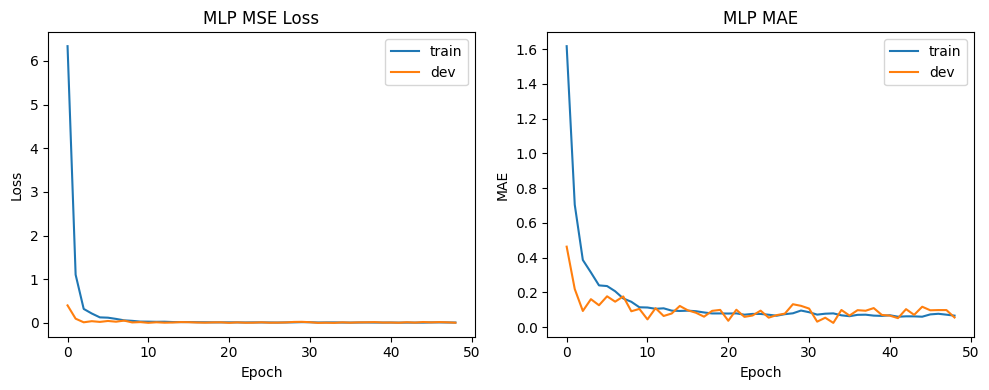

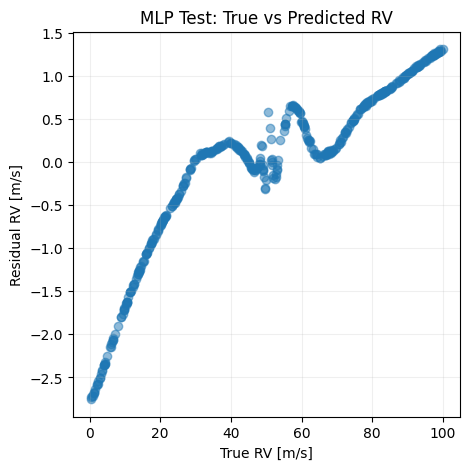

In [55]:
# MLP training curves
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history["loss"], label="train")
plt.plot(history.history["val_loss"], label="dev")
plt.title("MLP MSE Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history["mae"], label="train")
plt.plot(history.history["val_mae"], label="dev")
plt.title("MLP MAE")
plt.xlabel("Epoch")
plt.ylabel("MAE")
plt.legend()
plt.tight_layout()
plt.show()

# MLP prediction scatter on test split
plt.figure(figsize=(5, 5))
plt.scatter(y_test.ravel(), y_test.ravel() - y_test_pred, alpha=0.5)
min_v = min(y_test.min(), y_test_pred.min())
max_v = max(y_test.max(), y_test_pred.max())
#plt.plot([min_v, max_v], [min_v, max_v], "r--", linewidth=1)
plt.xlabel("True RV [m/s]")
plt.ylabel("Residual RV [m/s]")
plt.title("MLP Test: True vs Predicted RV")
plt.grid(True, alpha=0.2)
plt.show()


## Hybrid Model: Baseline RV + CNN Delta

This model predicts only the residual: `delta = rv_true - rv_baseline`.
Final prediction is `rv_pred = rv_baseline + delta_pred`.


In [56]:
# Build residual targets and CNN inputs (no pooling localization CNN)
delta_train = y_train.ravel() - rv_base_train
delta_dev = y_dev.ravel() - rv_base_dev
delta_test = y_test.ravel() - rv_base_test

delta_scaler = StandardScaler()
delta_train_s = delta_scaler.fit_transform(delta_train.reshape(-1, 1))
delta_dev_s = delta_scaler.transform(delta_dev.reshape(-1, 1))
delta_test_s = delta_scaler.transform(delta_test.reshape(-1, 1))

# Localization-friendly: single channel, keep positional detail.
X_train_loc = X_train_s[..., None].astype(np.float32)
X_dev_loc = X_dev_s[..., None].astype(np.float32)
X_test_loc = X_test_s[..., None].astype(np.float32)

print("X_train_loc:", X_train_loc.shape)
print("X_dev_loc:  ", X_dev_loc.shape)
print("X_test_loc: ", X_test_loc.shape)
print("Delta train std [m/s]:", float(np.std(delta_train)))


X_train_loc: (2100, 3001, 1)
X_dev_loc:   (450, 3001, 1)
X_test_loc:  (450, 3001, 1)
Delta train std [m/s]: 0.030629154294729233


In [63]:
def build_delta_localizer(n_features):
    inputs = keras.Input(shape=(n_features, 1))

    x = layers.Conv1D(32, kernel_size=11, padding="same", activation="relu")(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Conv1D(64, kernel_size=7, padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv1D(64, kernel_size=5, padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)

    # Keep localization detail: no max pooling / no global pooling.
    x = layers.Flatten()(x)
    x = layers.Dense(128, activation="relu")(x)
    x = layers.Dropout(0.2)(x)
    outputs = layers.Dense(1)(x)

    model = keras.Model(inputs, outputs)
    model.compile(
        optimizer=keras.optimizers.Adam(1e-4),
        loss=keras.losses.Huber(delta=1.0),
        metrics=[keras.metrics.MeanAbsoluteError(name="mae")],
    )
    return model

hybrid_model = build_delta_localizer(X_train_loc.shape[1])
hybrid_callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=20,
        restore_best_weights=True,
    )
]

hybrid_history = hybrid_model.fit(
    X_train_loc,
    delta_train_s,
    validation_data=(X_dev_loc, delta_dev_s),
    epochs=100,
    batch_size=128,
    callbacks=hybrid_callbacks,
    verbose=1,
)


Epoch 1/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 18s 921ms/step - loss: 8.1330 - mae: 8.6134 - val_loss: 0.5364 - val_mae: 0.9542
Epoch 2/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 15s 901ms/step - loss: 2.9694 - mae: 3.4120 - val_loss: 0.4677 - val_mae: 0.8853
Epoch 3/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 18s 1s/step - loss: 1.4139 - mae: 1.8397 - val_loss: 0.4651 - val_mae: 0.8852
Epoch 4/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 22s 1s/step - loss: 0.6306 - mae: 1.0324 - val_loss: 0.4799 - val_mae: 0.9067
Epoch 5/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 19s 1s/step - loss: 0.4897 - mae: 0.8878 - val_loss: 0.5077 - val_mae: 0.9342
Epoch 6/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 18s 1s/step - loss: 0.4433 - mae: 0.8400 - val_loss: 0.5064 - val_mae: 0.9342
Epoch 7/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 18s 1s/step - loss: 0.4123 - mae: 0.7981 - val_loss: 0.4951 - val_mae: 0.9249
Epoch 8/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 19s 1s/step - loss: 0.4030 - mae: 0.7948 - val_loss: 0.5101 - val_mae: 0.9409
Epoch 9/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 19s 1s/step - loss:

Dev (Hybrid)  -> MAE: 0.027113, RMSE: 0.030492, R2: 0.999999
Test (Hybrid) -> MAE: 0.026181, RMSE: 0.029667, R2: 0.999999


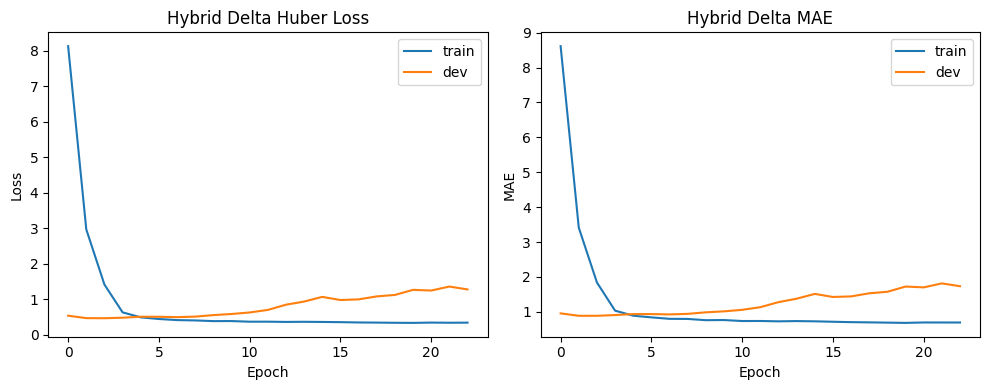

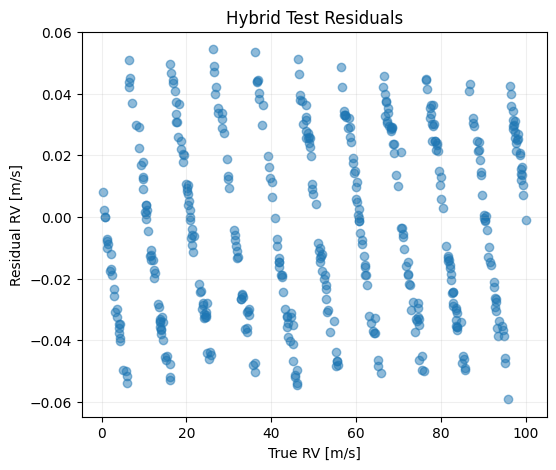

In [64]:
# Evaluate hybrid model: rv_pred = rv_baseline + delta_pred

delta_dev_pred_s = hybrid_model.predict(X_dev_loc, verbose=0)
delta_test_pred_s = hybrid_model.predict(X_test_loc, verbose=0)

delta_dev_pred = delta_scaler.inverse_transform(delta_dev_pred_s).ravel()
delta_test_pred = delta_scaler.inverse_transform(delta_test_pred_s).ravel()

y_dev_pred_hybrid = rv_base_dev + delta_dev_pred
y_test_pred_hybrid = rv_base_test + delta_test_pred

dev_mae = mean_absolute_error(y_dev.ravel(), y_dev_pred_hybrid)
dev_rmse = float(np.sqrt(mean_squared_error(y_dev.ravel(), y_dev_pred_hybrid)))
dev_r2 = r2_score(y_dev.ravel(), y_dev_pred_hybrid)

test_mae = mean_absolute_error(y_test.ravel(), y_test_pred_hybrid)
test_rmse = float(np.sqrt(mean_squared_error(y_test.ravel(), y_test_pred_hybrid)))
test_r2 = r2_score(y_test.ravel(), y_test_pred_hybrid)

print(f"Dev (Hybrid)  -> MAE: {dev_mae:.6f}, RMSE: {dev_rmse:.6f}, R2: {dev_r2:.6f}")
print(f"Test (Hybrid) -> MAE: {test_mae:.6f}, RMSE: {test_rmse:.6f}, R2: {test_r2:.6f}")

# Hybrid training curves
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(hybrid_history.history["loss"], label="train")
plt.plot(hybrid_history.history["val_loss"], label="dev")
plt.title("Hybrid Delta Huber Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(hybrid_history.history["mae"], label="train")
plt.plot(hybrid_history.history["val_mae"], label="dev")
plt.title("Hybrid Delta MAE")
plt.xlabel("Epoch")
plt.ylabel("MAE")
plt.legend()
plt.tight_layout()
plt.show()

# Residual trend vs true RV
res_hybrid = y_test.ravel() - y_test_pred_hybrid
plt.figure(figsize=(6, 5))
plt.scatter(y_test.ravel(), res_hybrid, alpha=0.5)
plt.xlabel("True RV [m/s]")
plt.ylabel("Residual RV [m/s]")
plt.title("Hybrid Test Residuals")
plt.grid(True, alpha=0.2)
plt.show()


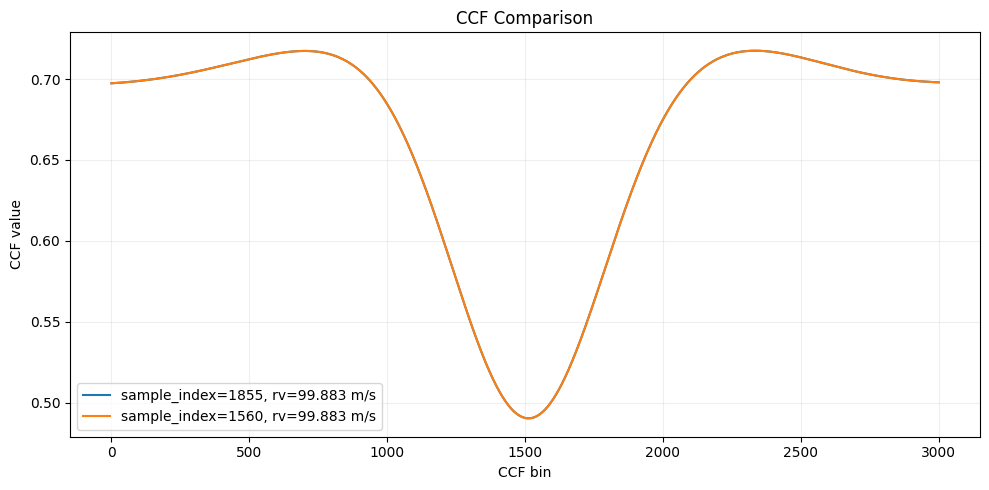

In [65]:
# Plot CCFs for sample_index 1855 and 1560
target_ids = [1855, 1560]

subset = df[df["sample_index"].isin(target_ids)].copy()
ccf_cols = [c for c in df.columns if c.startswith("ccf_")]

if subset.shape[0] != len(target_ids):
    found = subset["sample_index"].tolist()
    raise ValueError(f"Not all sample_index values found. Requested={target_ids}, Found={found}")

# Keep requested order
subset = subset.set_index("sample_index").loc[target_ids].reset_index()

plt.figure(figsize=(10, 5))
x = np.arange(len(ccf_cols))

for _, row in subset.iterrows():
    y_ccf = row[ccf_cols].to_numpy(dtype=float)
    plt.plot(x, y_ccf, label=f"sample_index={int(row['sample_index'])}, rv={row['rv_shift_ms']:.3f} m/s")

plt.xlabel("CCF bin")
plt.ylabel("CCF value")
plt.title("CCF Comparison")
plt.legend()
plt.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()


Raw performance
Dev (raw) -> MAE: 0.707555, RMSE: 0.967797, R2: 0.998795
Test (raw) -> MAE: 0.731367, RMSE: 0.978999, R2: 0.998887

Calibration: y_cal = 1.031485 * y_pred + -1.607079

Calibrated performance
Dev (cal) -> MAE: 0.364945, RMSE: 0.450598, R2: 0.999739
Test (cal) -> MAE: 0.335530, RMSE: 0.420496, R2: 0.999795


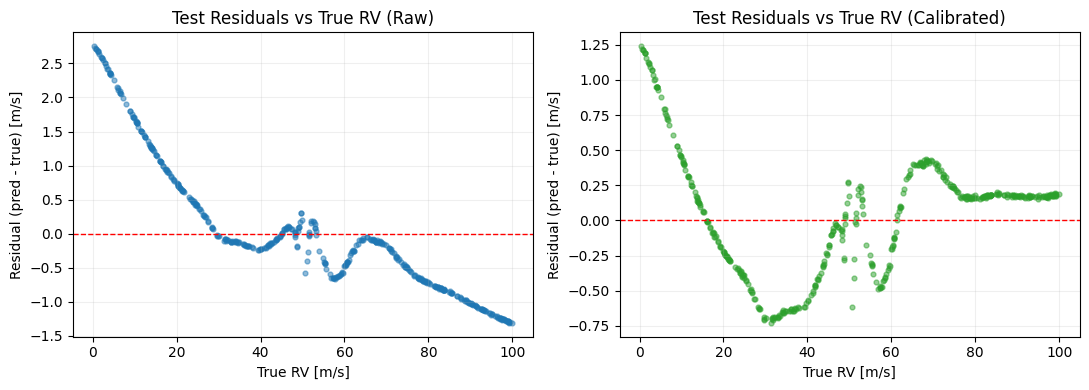

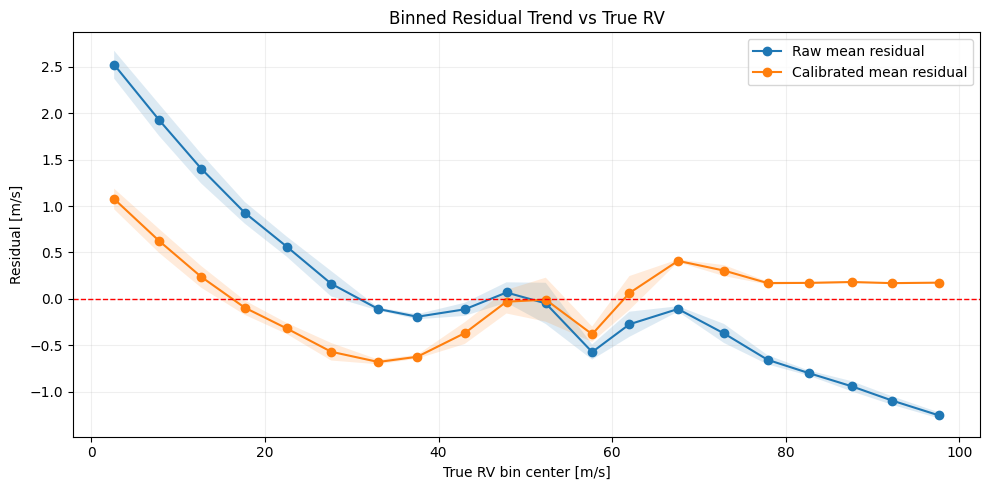

In [66]:
# Residual diagnostics vs true RV + post-hoc linear calibration (fit on DEV, apply to TEST)

import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# ---- Inputs expected from your notebook ----
# y_dev, y_test: true targets in original units (shape [n,1] or [n])
# y_dev_pred, y_test_pred: model predictions in original units (MLP or CNN)

y_dev_true = np.asarray(y_dev).ravel()
y_test_true = np.asarray(y_test).ravel()
y_dev_pred_raw = np.asarray(y_dev_pred).ravel()      # or y_dev_pred_cnn
y_test_pred_raw = np.asarray(y_test_pred).ravel()    # or y_test_pred_cnn

# ---- 1) Raw metrics ----
def reg_metrics(y_true, y_pred, label):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))
    r2 = r2_score(y_true, y_pred)
    print(f"{label} -> MAE: {mae:.6f}, RMSE: {rmse:.6f}, R2: {r2:.6f}")
    return mae, rmse, r2

print("Raw performance")
reg_metrics(y_dev_true, y_dev_pred_raw, "Dev (raw)")
reg_metrics(y_test_true, y_test_pred_raw, "Test (raw)")

# ---- 2) Fit calibration on DEV only: y_true = a * y_pred + b ----
cal = LinearRegression()
cal.fit(y_dev_pred_raw.reshape(-1, 1), y_dev_true)

a = float(cal.coef_[0])
b = float(cal.intercept_)
print(f"\nCalibration: y_cal = {a:.6f} * y_pred + {b:.6f}")

y_dev_pred_cal = cal.predict(y_dev_pred_raw.reshape(-1, 1))
y_test_pred_cal = cal.predict(y_test_pred_raw.reshape(-1, 1))

print("\nCalibrated performance")
reg_metrics(y_dev_true, y_dev_pred_cal, "Dev (cal)")
reg_metrics(y_test_true, y_test_pred_cal, "Test (cal)")

# ---- 3) Residual vs true RV plots (raw and calibrated on TEST) ----
res_raw = y_test_pred_raw - y_test_true
res_cal = y_test_pred_cal - y_test_true

plt.figure(figsize=(11, 4))
plt.subplot(1, 2, 1)
plt.scatter(y_test_true, res_raw, s=12, alpha=0.5, label="raw")
plt.axhline(0.0, color="r", linestyle="--", linewidth=1)
plt.xlabel("True RV [m/s]")
plt.ylabel("Residual (pred - true) [m/s]")
plt.title("Test Residuals vs True RV (Raw)")
plt.grid(True, alpha=0.2)

plt.subplot(1, 2, 2)
plt.scatter(y_test_true, res_cal, s=12, alpha=0.5, label="calibrated", color="tab:green")
plt.axhline(0.0, color="r", linestyle="--", linewidth=1)
plt.xlabel("True RV [m/s]")
plt.ylabel("Residual (pred - true) [m/s]")
plt.title("Test Residuals vs True RV (Calibrated)")
plt.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

# ---- 4) Binned mean residual vs RV (raw vs calibrated) ----
n_bins = 20
edges = np.linspace(y_test_true.min(), y_test_true.max(), n_bins + 1)
bin_id = np.digitize(y_test_true, edges) - 1

centers, mean_raw, std_raw, mean_cal, std_cal = [], [], [], [], []
for bidx in range(n_bins):
    m = bin_id == bidx
    if np.any(m):
        centers.append(float(y_test_true[m].mean()))
        mean_raw.append(float(res_raw[m].mean()))
        std_raw.append(float(res_raw[m].std()))
        mean_cal.append(float(res_cal[m].mean()))
        std_cal.append(float(res_cal[m].std()))

centers = np.array(centers)
mean_raw = np.array(mean_raw)
std_raw = np.array(std_raw)
mean_cal = np.array(mean_cal)
std_cal = np.array(std_cal)

plt.figure(figsize=(10, 5))
plt.plot(centers, mean_raw, marker="o", label="Raw mean residual")
plt.fill_between(centers, mean_raw - std_raw, mean_raw + std_raw, alpha=0.15)

plt.plot(centers, mean_cal, marker="o", label="Calibrated mean residual")
plt.fill_between(centers, mean_cal - std_cal, mean_cal + std_cal, alpha=0.15)

plt.axhline(0.0, color="r", linestyle="--", linewidth=1)
plt.xlabel("True RV bin center [m/s]")
plt.ylabel("Residual [m/s]")
plt.title("Binned Residual Trend vs True RV")
plt.legend()
plt.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()


Mode counts: {'gaussian': 450}
Baseline MAE (test): 28.457220 m/s
Hybrid   MAE (test): 0.026181 m/s


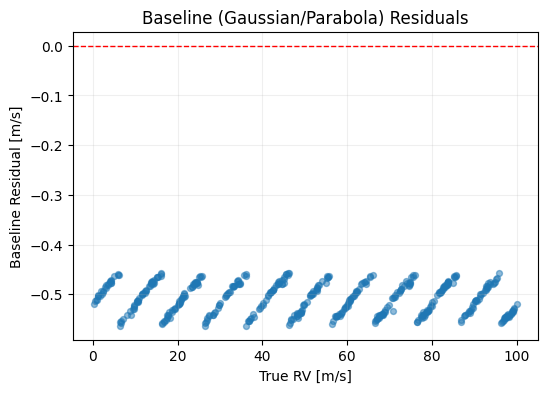

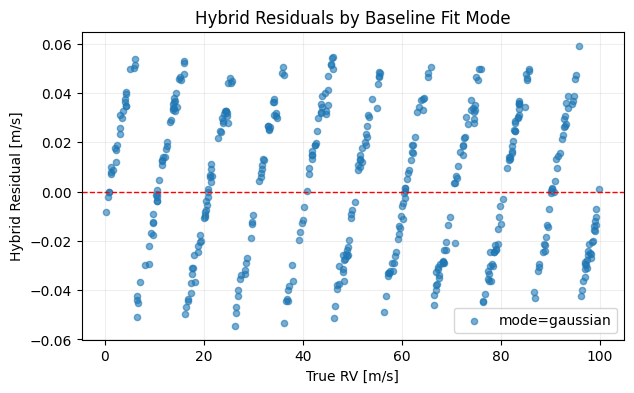

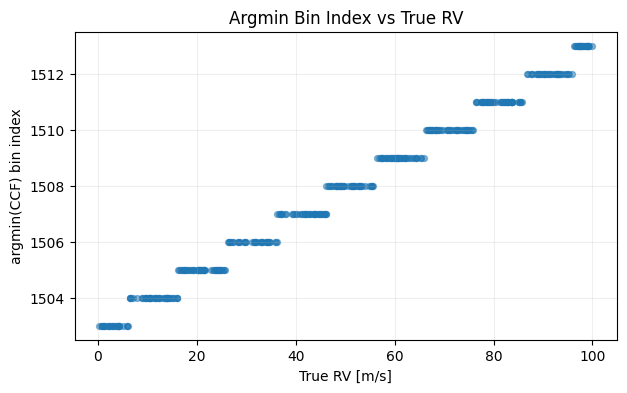

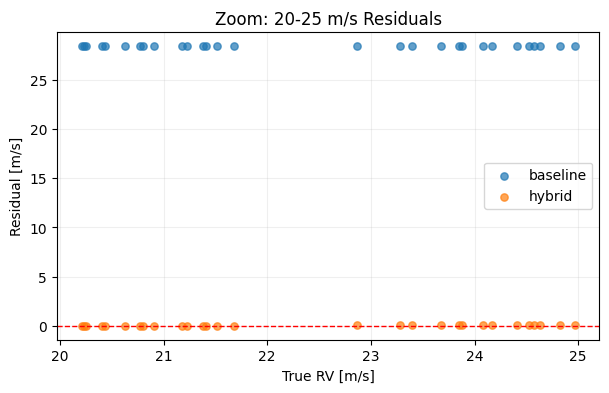

In [67]:
# Baseline diagnostics: identify localized residual artifacts

def estimate_rv_baseline_with_mode(ccf_vec, vrad_grid, window_half=6):
    idx0 = int(np.argmin(ccf_vec))
    lo = max(0, idx0 - window_half)
    hi = min(len(vrad_grid), idx0 + window_half + 1)

    v_win = vrad_grid[lo:hi].astype(np.float64)
    y_win = ccf_vec[lo:hi].astype(np.float64)

    try:
        cont0 = float(np.max(y_win))
        amp0 = float(max(cont0 - np.min(y_win), 1e-6))
        mu0 = float(vrad_grid[idx0])
        sigma0 = 0.3

        popt, _ = curve_fit(
            _gaussian_absorption,
            v_win,
            y_win,
            p0=[amp0, mu0, sigma0, cont0],
            bounds=([0.0, v_win.min(), 0.02, 0.0], [np.inf, v_win.max(), 5.0, 2.0]),
            maxfev=10000,
        )
        rv_ms = float(popt[1] * 1000.0)
        return rv_ms, "gaussian", idx0
    except Exception:
        if 0 < idx0 < (len(vrad_grid) - 1):
            x = vrad_grid[idx0 - 1: idx0 + 2].astype(np.float64)
            z = ccf_vec[idx0 - 1: idx0 + 2].astype(np.float64)
            a, b, _ = np.polyfit(x, z, 2)
            if abs(a) > 1e-12:
                xv = -b / (2.0 * a)
                return float(xv * 1000.0), "parabola", idx0
        return float(vrad_grid[idx0] * 1000.0), "argmin", idx0

# Recompute baseline details on test split
baseline_info = [estimate_rv_baseline_with_mode(row, ccf_vrad) for row in X_test]
rv_base_test_diag = np.array([t[0] for t in baseline_info], dtype=np.float64)
mode_test = np.array([t[1] for t in baseline_info], dtype=object)
argmin_idx_test = np.array([t[2] for t in baseline_info], dtype=int)

y_test_true = y_test.ravel().astype(np.float64)
res_base = rv_base_test_diag - y_test_true
res_hybrid = y_test_pred_hybrid - y_test_true

print("Mode counts:", pd.Series(mode_test).value_counts().to_dict())
print(f"Baseline MAE (test): {mean_absolute_error(y_test_true, rv_base_test_diag):.6f} m/s")
print(f"Hybrid   MAE (test): {mean_absolute_error(y_test_true, y_test_pred_hybrid):.6f} m/s")

# 1) Baseline-only residual vs true RV
plt.figure(figsize=(6, 4))
plt.scatter(y_test_true, res_base-28.965262, alpha=0.5, s=18)
plt.axhline(0.0, color="r", linestyle="--", linewidth=1)
plt.xlabel("True RV [m/s]")
plt.ylabel("Baseline Residual [m/s]")
plt.title("Baseline (Gaussian/Parabola) Residuals")
plt.grid(True, alpha=0.2)
plt.show()

# 2) Hybrid residual split by fit mode
plt.figure(figsize=(7, 4))
for m in np.unique(mode_test):
    mask = mode_test == m
    plt.scatter(y_test_true[mask], res_hybrid[mask], alpha=0.6, s=20, label=f"mode={m}")
plt.axhline(0.0, color="r", linestyle="--", linewidth=1)
plt.xlabel("True RV [m/s]")
plt.ylabel("Hybrid Residual [m/s]")
plt.title("Hybrid Residuals by Baseline Fit Mode")
plt.legend()
plt.grid(True, alpha=0.2)
plt.show()

# 3) Argmin index transitions vs RV
plt.figure(figsize=(7, 4))
plt.scatter(y_test_true, argmin_idx_test, alpha=0.5, s=18)
plt.xlabel("True RV [m/s]")
plt.ylabel("argmin(CCF) bin index")
plt.title("Argmin Bin Index vs True RV")
plt.grid(True, alpha=0.2)
plt.show()

# 4) Zoom suspicious region (20-25 m/s)
zoom_mask = (y_test_true >= 20.0) & (y_test_true <= 25.0)
if np.any(zoom_mask):
    plt.figure(figsize=(7, 4))
    plt.scatter(y_test_true[zoom_mask], res_base[zoom_mask], s=28, alpha=0.7, label="baseline")
    plt.scatter(y_test_true[zoom_mask], res_hybrid[zoom_mask], s=28, alpha=0.7, label="hybrid")
    plt.axhline(0.0, color="r", linestyle="--", linewidth=1)
    plt.xlabel("True RV [m/s]")
    plt.ylabel("Residual [m/s]")
    plt.title("Zoom: 20-25 m/s Residuals")
    plt.legend()
    plt.grid(True, alpha=0.2)
    plt.show()
else:
    print("No test samples in 20-25 m/s range.")


(array([ 8.,  9.,  6., 11.,  8.,  8., 11., 10.,  6., 12., 13., 12., 11.,
         9., 13., 15.,  8., 11.,  7., 10., 11.,  8.,  5.,  7.,  5.,  8.,
        14., 10., 18., 12., 11.,  9., 11.,  8., 10., 16.,  7., 14.,  9.,
        10., 11., 17.,  7., 11., 10., 19., 11.,  5., 13., 11., 12.,  8.,
        14.,  7.,  9.,  7., 14.,  8.,  9., 13., 13., 10.,  9.,  7., 16.,
         7.,  7., 11., 10.,  9., 11.,  9., 12., 15., 10.,  8.,  8., 13.,
        10., 11.,  2., 15.,  8.,  8.,  9., 13., 12.,  6., 11.,  6., 11.,
         7.,  6.,  7., 12., 12., 16.,  9., 10.,  7., 10., 11., 11.,  9.,
         6.,  8.,  5.,  5.,  8.,  9., 10., 11., 10., 13.,  7.,  9.,  7.,
        12., 15., 10., 12.,  6., 12., 10., 12., 16.,  8.,  8.,  7., 12.,
        10., 15.,  7., 12., 12.,  9., 12.,  9., 11., 13., 16., 10., 11.,
        11., 12.,  4.,  7., 10., 14., 10., 11., 14.,  9.,  5., 11.,  9.,
        16.,  7., 11., 15.,  9.,  8.,  6.,  5., 10.,  9., 17.,  6., 12.,
        11., 12., 10.,  6.,  6., 11., 11., 11., 11.

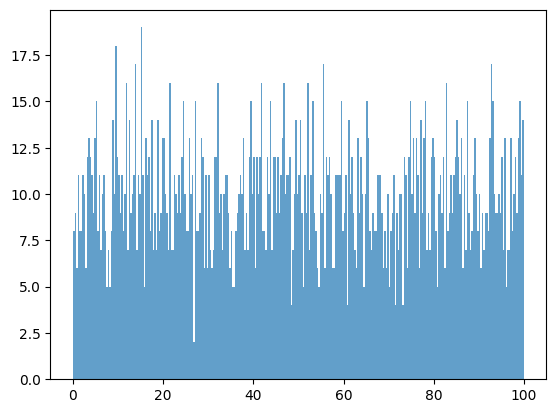

In [81]:
plt.hist(y, bins=300, alpha=0.7)